# UC3 — Cascade Configuration Comparison

## Purpose

Empirically determine the optimal cascade configuration for UC3 web attack detection by comparing single-layer, two-layer, three-layer, and four-layer compositions of the persisted L1 (Regex), L2 (OC-SVM), L3 (XGBoost), and L4 (Isolation Forest) detectors.

## Why this notebook exists

`Plan.md` specifies a 2-layer cascade (Regex + XGBoost). The current implementation runs a 3-layer cascade (Regex + OC-SVM + XGBoost), and a second unsupervised detector (Isolation Forest) is also persisted (`models/web_attack_if.pkl`) but not wired into any cascade. This notebook resolves the discrepancy with empirical evidence on the CSIC 2010 test set, and exhaustively checks whether *either* unsupervised model — alone, together, or alongside XGBoost — is worth keeping.

## Cascade prediction semantics

For a cascade composed of layers $\{L_i\}$, a request is flagged iff *any* layer flags it. With **fixed per-layer thresholds**, this is equivalent to a logical union over layer predictions, regardless of execution order:

$$	ext{pred}(x) = \max_i L_i(x)$$

Execution order affects runtime cost (cheap layers first to short-circuit expensive ones) but not the final classification, since OR is commutative/associative over fixed per-layer outputs. We therefore compare **subsets** of layers, not orderings — "regex first" and "unsupervised first" are equivalent execution strategies of the *same* configuration, and only the layer subset is varied below.

## Configurations compared

Regex (L1) is always included whenever any other layer is — it is free (no model inference) and never the variable under test.

| ID  | Layers              | Case                                      | Notes                                 |
|-----|----------------------|--------------------------------------------|----------------------------------------|
| C1  | L1                   | Regex baseline                            | Signature-only                         |
| C2  | L2                   | OC-SVM standalone                         | Unsupervised, no regex                 |
| C3  | L3                   | XGBoost standalone                        | Supervised, no regex                   |
| C4  | L4                   | Isolation Forest standalone                | Unsupervised, no regex                 |
| C5  | L1 + L2              | Unsupervised only (OC-SVM)                | Regex + one unsupervised model         |
| C6  | L1 + L4              | Unsupervised only (Isolation Forest)      | Regex + one unsupervised model         |
| C7  | L1 + L2 + L4         | Unsupervised only (both)                  | Regex + both unsupervised models       |
| C8  | L1 + L3              | XGBoost only                              | 2-layer (Plan.md spec) — **expected best** |
| C9  | L1 + L2 + L3         | One unsupervised (OC-SVM) + XGBoost       | 3-layer (current implementation)       |
| C10 | L1 + L4 + L3         | One unsupervised (Isolation Forest) + XGBoost | 3-layer (alternate unsupervised model) |
| C11 | L1 + L2 + L4 + L3    | Both unsupervised + XGBoost               | 4-layer (everything)                   |

## Data split

- **Test benign:** full `normalTrafficTest.csv`
- **Test attack:** **second 50%** of `anomalousTrafficTest.csv`
  (first 50% was used to train L3 — evaluating on it would leak)
- L1 (Regex): no training data
- L2 (OC-SVM): trained on benign-only
- L3 (XGBoost): trained on benign + first 50% of attacks
- L4 (Isolation Forest): trained on benign-only

## Inputs

- CSV files
- Persisted OC-SVM artifact: `models/web_attack_ocsvm.pkl`
- Persisted XGBoost artifact: `models/web_attack_xgboost.pkl`
- Persisted Isolation Forest artifact: `models/web_attack_if.pkl`

In [1]:
import os
import re
import math
import numpy as np
import pandas as pd
import joblib
from urllib.parse import unquote, urlparse, parse_qs

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ── Configuration ──────────────────────────────────────────────────────
CSV_DIR   = "./data"
MODEL_DIR = "./models"

STRUCTURAL_FEATURE_COLS = [
    "request_length", "special_char_count", "special_char_ratio",
    "url_entropy", "body_entropy", "param_count",
    "max_param_value_length", "url_path_depth", "has_body",
]
VOCAB_FEATURE_COLS = [
    "unknown_param_name_count",
    "unknown_param_name_ratio",
    "max_param_name_min_edit_dist",
]
FEATURE_COLS = STRUCTURAL_FEATURE_COLS + VOCAB_FEATURE_COLS

# Must match the split used in web_attack_xgboost.ipynb
ATTACK_SPLIT = 0.5

print("Ready.")

Ready.


## 1. Load Test Data

Use only the **second 50%** of `anomalousTrafficTest` — the first 50% was used to train L3 (XGBoost). This prevents data leakage.

In [2]:
df_test_benign = pd.read_csv(os.path.join(CSV_DIR, "normalTrafficTest.csv"))
df_attack_all  = pd.read_csv(os.path.join(CSV_DIR, "anomalousTrafficTest.csv"))

split_idx = int(len(df_attack_all) * ATTACK_SPLIT)
df_test_attack = df_attack_all.iloc[split_idx:].copy().reset_index(drop=True)

df_test = pd.concat([df_test_benign, df_test_attack], ignore_index=True)
y_test  = df_test["label"].values

total_benign = (y_test == 0).sum()
total_attack = (y_test == 1).sum()

print(f"Test benign: {len(df_test_benign):>6,}")
print(f"Test attack: {len(df_test_attack):>6,}  (second {1-ATTACK_SPLIT:.0%} of anomalousTrafficTest)")
print(f"Test total:  {len(df_test):>6,}")

Test benign: 36,000
Test attack: 12,533  (second 50% of anomalousTrafficTest)
Test total:  48,533


## 2. Feature Extraction

Identical `extract_features()` and `ParamVocab` definitions used in the L2/L3 training notebooks — guarantees training-inference feature parity. URL-decoded **before** computing features.

In [3]:
SPECIAL_CHARS = set("'\";<>(){}[]|$`!@#%^*~")

def _shannon_entropy(s: str) -> float:
    if not s:
        return 0.0
    length = len(s)
    freq = {}
    for ch in s:
        freq[ch] = freq.get(ch, 0) + 1
    return -sum((c / length) * math.log2(c / length) for c in freq.values())


def _count_special_chars(s: str) -> int:
    return sum(1 for ch in s if ch in SPECIAL_CHARS)


def _count_params(url: str, body: str, content_type: str) -> int:
    n = 0
    # URL query params
    try:
        parsed = urlparse(url)
        n += len(parse_qs(parsed.query, keep_blank_values=True))
    except Exception:
        pass
    # POST body params (only for form-urlencoded)
    if isinstance(body, str) and isinstance(content_type, str):
        if "application/x-www-form-urlencoded" in content_type.lower():
            try:
                n += len(parse_qs(body, keep_blank_values=True))
            except Exception:
                pass
    return n

def _max_param_value_length(url: str, body: str, content_type: str) -> int:
    vals = []

    try:
        parsed = urlparse(url)
        for v_list in parse_qs(parsed.query, keep_blank_values=True).values():
            vals.extend(v_list)
    except Exception:
        pass

    if isinstance(body, str) and isinstance(content_type, str):
        if "application/x-www-form-urlencoded" in content_type.lower():
            try:
                for v_list in parse_qs(body, keep_blank_values=True).values():
                    vals.extend(v_list)
            except Exception:
                pass

    return max((len(v) for v in vals), default=0)


def _url_path_depth(url: str) -> int:
    try:
        path = urlparse(url).path
        segments = [s for s in path.split("/") if s]
        return len(segments)
    except Exception:
        return 0


def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    # URL-decode first
    decoded_url  = df["url"].fillna("").apply(lambda u: unquote(u))
    decoded_body = df["body"].fillna("")

    # Reconstruct full request string for request_length
    full_request = (
        df["method"].fillna("") + " "
        + decoded_url + " "
        + df["protocol"].fillna("") + "\n"
        + df["headers_raw"].fillna("") + "\n\n"
        + decoded_body
    )

    combined = decoded_url + decoded_body
    spec_count = combined.apply(_count_special_chars)
    combined_len = combined.str.len().replace(0, 1)  # avoid div-by-zero

    features = pd.DataFrame({
        "request_length":       full_request.str.len(),
        "special_char_count":   spec_count,
        "special_char_ratio":   spec_count / combined_len,
        "url_entropy":          decoded_url.apply(_shannon_entropy),
        "body_entropy":         decoded_body.apply(_shannon_entropy),
        "param_count":          [
            _count_params(u, b, ct)
            for u, b, ct in zip(
                decoded_url, decoded_body, df["content_type"].fillna(""),
            )
        ],
        "max_param_value_length": [
            _max_param_value_length(u, b, ct)
            for u, b, ct in zip(
                decoded_url, decoded_body, df["content_type"].fillna(""),
            )
        ],
        "url_path_depth":       decoded_url.apply(_url_path_depth),
        "has_body":             (decoded_body.str.len() > 0).astype(int),
    })
    return features


print("Feature extraction function defined.")

class ParamVocab:
    """Parameter-name vocabulary learned from benign traffic."""

    def __init__(self):
        self.known_names: set = set()

    @staticmethod
    def _parse_params(url: str, body: str, content_type: str) -> dict:
        params = {}
        try:
            parsed = urlparse(unquote(url))
            params.update(parse_qs(parsed.query, keep_blank_values=True))
        except Exception:
            pass
        if isinstance(body, str) and isinstance(content_type, str):
            if "application/x-www-form-urlencoded" in content_type.lower():
                try:
                    params.update(parse_qs(body, keep_blank_values=True))
                except Exception:
                    pass
        return params

    @staticmethod
    def _levenshtein(s1: str, s2: str) -> int:
        if len(s1) < len(s2):
            return ParamVocab._levenshtein(s2, s1)
        if not s2:
            return len(s1)
        prev = list(range(len(s2) + 1))
        for i, c1 in enumerate(s1):
            curr = [i + 1]
            for j, c2 in enumerate(s2):
                curr.append(min(
                    curr[j] + 1,
                    prev[j + 1] + 1,
                    prev[j] + (0 if c1 == c2 else 1),
                ))
            prev = curr
        return prev[-1]

    def fit(self, df: pd.DataFrame) -> "ParamVocab":
        self.known_names = set()
        for url, body, ct in zip(
            df["url"].fillna(""),
            df["body"].fillna(""),
            df["content_type"].fillna(""),
        ):
            self.known_names.update(
                self._parse_params(url, body, ct).keys()
            )
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        records = []
        for url, body, ct in zip(
            df["url"].fillna(""),
            df["body"].fillna(""),
            df["content_type"].fillna(""),
        ):
            names = list(self._parse_params(url, body, ct).keys())
            total = len(names)

            if total == 0:
                records.append((0, 0.0, 0))
                continue

            unknown_count = sum(1 for n in names if n not in self.known_names)

            # Edit distance only for unknown names (known → 0, skip)
            max_min_ed = 0
            for name in names:
                if name in self.known_names:
                    continue
                if not self.known_names:
                    min_ed = len(name)
                else:
                    min_ed = min(
                        self._levenshtein(name, kn)
                        for kn in self.known_names
                    )
                max_min_ed = max(max_min_ed, min_ed)

            records.append((
                unknown_count,
                unknown_count / total,
                max_min_ed,
            ))

        return pd.DataFrame(
            records,
            columns=VOCAB_FEATURE_COLS,
            index=df.index,
        )

print("ParamVocab defined.")

Feature extraction function defined.
ParamVocab defined.


## 3. Layer 1 — Regex Rule Engine

Signature-based detection for known attack families. No training required. Covers SQLi, XSS, path traversal, and command injection.

In [4]:
SIGNATURES = [
    # SQL Injection
    re.compile(
        r"(?:'\s*(?:OR|AND|UNION|SELECT|INSERT|UPDATE|DELETE|DROP|ALTER|CREATE"
        r"|EXEC|EXECUTE|HAVING|ORDER\s+BY|GROUP\s+BY)\b"
        r"|\b(?:UNION\s+(?:ALL\s+)?SELECT|SELECT\s+.+\s+FROM|INSERT\s+INTO"
        r"|UPDATE\s+\w+\s+SET|DELETE\s+FROM|DROP\s+(?:TABLE|DATABASE)"
        r"|ALTER\s+TABLE|EXEC(?:UTE)?\s)\b"
        r"|--\s*$|/\*.*?\*/|;\s*(?:DROP|SELECT|INSERT|UPDATE|DELETE)\b"
        r"|'\s*;\s*--|'\s+OR\s+'\d+'\s*=\s*'\d+)",
        re.IGNORECASE,
    ),
    # XSS
    re.compile(
        r"(?:<\s*script[^>]*>|javascript\s*:|on(?:error|load|click|mouse\w+|focus"
        r"|blur|submit|change|key\w+|dblclick|drag\w*|drop|scroll|resize"
        r"|unload|beforeunload|hashchange|popstate|storage|message|online"
        r"|offline|contextmenu|input|invalid|search|select|wheel|copy|cut"
        r"|paste|abort|canplay\w*|durationchange|emptied|ended|loadeddata"
        r"|loadedmetadata|loadstart|pause|play|playing|progress|ratechange"
        r"|seeked|seeking|stalled|suspend|timeupdate|volumechange|waiting)\s*="
        r"|<\s*(?:img|iframe|object|embed|svg|body)\b[^>]*\bon\w+\s*=)",
        re.IGNORECASE,
    ),
    # Path Traversal / LFI
    re.compile(
        r"(?:\.\.\/\.\.\/|\.\.\\\.\.\\"
        r"|/etc/(?:passwd|shadow|hosts|group|resolv\.conf)"
        r"|/proc/self|/var/log/\w+"
        r"|\.\.[\/]\.\.[\/]\.\.[\/])",
        re.IGNORECASE,
    ),
    # Command Injection
    re.compile(
        r"(?:[;|`]\s*(?:cat|ls|whoami|uname|id|wget|curl|nc|bash|sh|cmd)\b"
        r"|\$\(\s*\w|\b(?:powershell|netcat)\b)",
        re.IGNORECASE,
    ),
]


def layer1_predict(df: pd.DataFrame) -> np.ndarray:
    """Apply regex signatures. Returns 1 (attack) if any pattern matches, else 0."""
    urls   = df["url"].fillna("").astype(str)
    bodies = df["body"].fillna("").astype(str)
    full   = (urls + " " + bodies).apply(unquote)

    flags = np.zeros(len(df), dtype=int)
    for i, text in enumerate(full):
        for sig in SIGNATURES:
            if sig.search(text):
                flags[i] = 1
                break
    return flags


print(f"Layer 1 defined: {len(SIGNATURES)} signature patterns.")

Layer 1 defined: 4 signature patterns.


## 4. Load Persisted Layer 2 (OC-SVM), Layer 3 (XGBoost), and Layer 4 (Isolation Forest)

All three artifacts must contain a fitted `ParamVocab`. The cross-artifact vocab assertion guarantees feature parity across the persisted models — if it fails, one of the training notebooks needs to be re-run.

In [5]:
l2_art = joblib.load(os.path.join(MODEL_DIR, "web_attack_ocsvm.pkl"))
l3_art = joblib.load(os.path.join(MODEL_DIR, "web_attack_xgboost.pkl"))
l4_art = joblib.load(os.path.join(MODEL_DIR, "web_attack_if.pkl"))

# Cross-artifact vocab consistency
assert l2_art["vocab"].known_names == l3_art["vocab"].known_names == l4_art["vocab"].known_names, (
    "L2/L3/L4 vocabs differ — feature computation will be inconsistent"
)
vocab = l2_art["vocab"]

print(f"L2 (OC-SVM)            loaded: threshold = {l2_art['threshold']:.4f}")
print(f"L3 (XGBoost)            loaded: threshold = {l3_art['threshold']:.4f}")
print(f"L4 (Isolation Forest)   loaded: threshold = {l4_art['threshold']:.4f}")
print(f"Shared vocab:  {len(vocab.known_names)} known param names")


def layer2_predict(X_feat: pd.DataFrame) -> np.ndarray:
    scaled = l2_art["scaler"].transform(X_feat[FEATURE_COLS])
    scores = l2_art["model"].decision_function(scaled)
    return np.where(scores < l2_art["threshold"], 1, 0)


def layer3_predict(X_feat: pd.DataFrame) -> np.ndarray:
    scaled = l3_art["scaler"].transform(X_feat[FEATURE_COLS])
    probs  = l3_art["model"].predict_proba(scaled)[:, 1]
    return (probs >= l3_art["threshold"]).astype(int)


def layer4_predict(X_feat: pd.DataFrame) -> np.ndarray:
    scaled = l4_art["scaler"].transform(X_feat[FEATURE_COLS])
    scores = l4_art["model"].decision_function(scaled)
    return np.where(scores < l4_art["threshold"], 1, 0)


print("Prediction functions defined.")

L2 (OC-SVM)            loaded: threshold = -7.8409
L3 (XGBoost)            loaded: threshold = 0.7177
L4 (Isolation Forest)   loaded: threshold = -0.1172
Shared vocab:  20 known param names
Prediction functions defined.


## 5. Compute Feature Matrix (Shared Across L2, L3, and L4)

In [6]:
X_test = pd.concat([
    extract_features(df_test),
    vocab.transform(df_test),
], axis=1)

print(f"Feature matrix: {X_test.shape}")

Feature matrix: (48533, 12)


## 6. Compute Per-Layer Predictions

Each layer is applied independently to the full test set. Cascade configurations are then defined as logical unions of these per-layer predictions.

In [7]:
y_l1 = layer1_predict(df_test)
y_l2 = layer2_predict(X_test)
y_l3 = layer3_predict(X_test)
y_l4 = layer4_predict(X_test)

print(f"L1 (Regex)            flagged: {y_l1.sum():>6,} / {len(y_l1):,}")
print(f"L2 (OC-SVM)           flagged: {y_l2.sum():>6,} / {len(y_l2):,}")
print(f"L3 (XGBoost)          flagged: {y_l3.sum():>6,} / {len(y_l3):,}")
print(f"L4 (Isolation Forest) flagged: {y_l4.sum():>6,} / {len(y_l4):,}")

L1 (Regex)            flagged:  1,106 / 48,533
L2 (OC-SVM)           flagged:  9,275 / 48,533
L3 (XGBoost)          flagged: 11,369 / 48,533
L4 (Isolation Forest) flagged:  6,140 / 48,533


---
# Configuration Comparison

## 7. Define Configurations

Each configuration is the logical union (`np.maximum`) of its component layers' predictions.

In [8]:
configurations = [
    ("C1",  "L1",                "Regex baseline",                       y_l1),
    ("C2",  "L2",                "OC-SVM standalone",                    y_l2),
    ("C3",  "L3",                "XGBoost standalone",                   y_l3),
    ("C4",  "L4",                "Isolation Forest standalone",          y_l4),
    ("C5",  "L1 + L2",           "Unsupervised only (OC-SVM)",           np.maximum(y_l1, y_l2)),
    ("C6",  "L1 + L4",           "Unsupervised only (Isolation Forest)", np.maximum(y_l1, y_l4)),
    ("C7",  "L1 + L2 + L4",      "Unsupervised only (both)",             np.maximum.reduce([y_l1, y_l2, y_l4])),
    ("C8",  "L1 + L3",           "XGBoost only (Plan.md spec)",          np.maximum(y_l1, y_l3)),
    ("C9",  "L1 + L2 + L3",      "OC-SVM + XGBoost",                     np.maximum.reduce([y_l1, y_l2, y_l3])),
    ("C10", "L1 + L4 + L3",      "Isolation Forest + XGBoost",           np.maximum.reduce([y_l1, y_l4, y_l3])),
    ("C11", "L1 + L2 + L4 + L3", "Everything",                           np.maximum.reduce([y_l1, y_l2, y_l4, y_l3])),
]

for cid, layers, case, pred in configurations:
    print(f"  {cid:<4} {layers:<18} {case:<40} flagged = {pred.sum():>6,}")

  C1   L1                 Regex baseline                           flagged =  1,106
  C2   L2                 OC-SVM standalone                        flagged =  9,275
  C3   L3                 XGBoost standalone                       flagged = 11,369
  C4   L4                 Isolation Forest standalone              flagged =  6,140
  C5   L1 + L2            Unsupervised only (OC-SVM)               flagged =  9,276
  C6   L1 + L4            Unsupervised only (Isolation Forest)     flagged =  6,140
  C7   L1 + L2 + L4       Unsupervised only (both)                 flagged = 11,425
  C8   L1 + L3            XGBoost only (Plan.md spec)              flagged = 11,371
  C9   L1 + L2 + L3       OC-SVM + XGBoost                         flagged = 11,724
  C10  L1 + L4 + L3       Isolation Forest + XGBoost               flagged = 13,426
  C11  L1 + L2 + L4 + L3  Everything                               flagged = 13,473


## 8. Metric Comparison

Precision, Recall, F1, and FPR for each configuration on the same held-out test set.

In [9]:
rows = []
for cid, layers, case, pred in configurations:
    tp = ((pred == 1) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()
    p  = precision_score(y_test, pred, zero_division=0)
    r  = recall_score(y_test, pred, zero_division=0)
    f  = f1_score(y_test, pred, zero_division=0)
    fpr = fp / total_benign
    rows.append({
        "ID": cid, "Configuration": layers, "Case": case,
        "Precision": p, "Recall": r, "F1": f, "FPR": fpr,
        "TP": tp, "FP": fp, "FN": fn,
    })

results = pd.DataFrame(rows)
results_display = results.copy()
for col in ["Precision", "Recall", "F1", "FPR"]:
    results_display[col] = results_display[col].apply(lambda x: f"{x:.4f}")

print(results_display.to_string(index=False))

 ID     Configuration                                 Case Precision Recall     F1    FPR    TP   FP    FN
 C1                L1                       Regex baseline    1.0000 0.0882 0.1622 0.0000  1106    0 11427
 C2                L2                    OC-SVM standalone    0.9582 0.7091 0.8150 0.0108  8887  388  3646
 C3                L3                   XGBoost standalone    0.9701 0.8800 0.9229 0.0094 11029  340  1504
 C4                L4          Isolation Forest standalone    0.7015 0.3437 0.4613 0.0509  4307 1833  8226
 C5           L1 + L2           Unsupervised only (OC-SVM)    0.9582 0.7092 0.8151 0.0108  8888  388  3645
 C6           L1 + L4 Unsupervised only (Isolation Forest)    0.7015 0.3437 0.4613 0.0509  4307 1833  8226
 C7      L1 + L2 + L4             Unsupervised only (both)    0.8330 0.7594 0.7945 0.0530  9517 1908  3016
 C8           L1 + L3          XGBoost only (Plan.md spec)    0.9701 0.8802 0.9229 0.0094 11031  340  1502
 C9      L1 + L2 + L3                

### 8.1 Best Configuration by Each Metric

In [10]:
best_f1_idx = results["F1"].idxmax()
best_p_idx  = results["Precision"].idxmax()
best_r_idx  = results["Recall"].idxmax()
best_fpr_idx = results["FPR"].idxmin()

print(f"Best F1:        {results.loc[best_f1_idx,  'Configuration']:<14}  F1  = {results.loc[best_f1_idx,  'F1']:.4f}")
print(f"Best Precision: {results.loc[best_p_idx,   'Configuration']:<14}  P   = {results.loc[best_p_idx,   'Precision']:.4f}")
print(f"Best Recall:    {results.loc[best_r_idx,   'Configuration']:<14}  R   = {results.loc[best_r_idx,   'Recall']:.4f}")
print(f"Lowest FPR:     {results.loc[best_fpr_idx, 'Configuration']:<14}  FPR = {results.loc[best_fpr_idx, 'FPR']:.4f}")

Best F1:        L1 + L3         F1  = 0.9229
Best Precision: L1              P   = 1.0000
Best Recall:    L1 + L2 + L4 + L3  R   = 0.9184
Lowest FPR:     L1              FPR = 0.0000


## 9. Visual Comparison

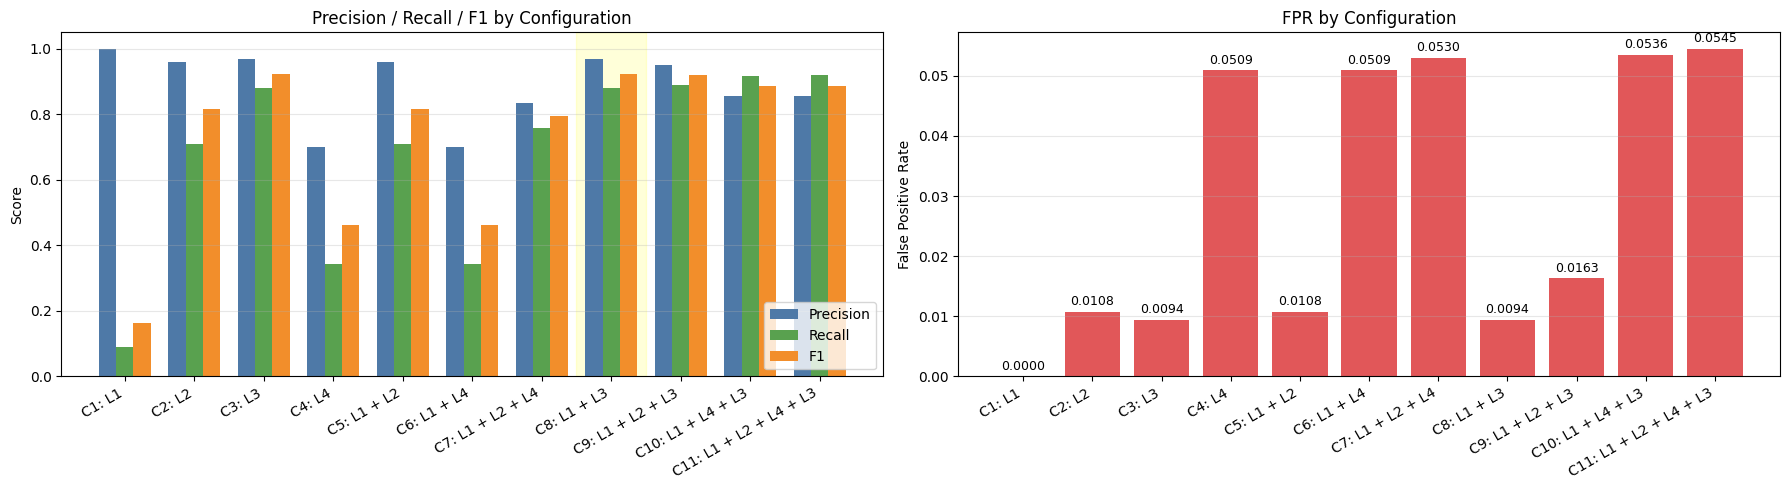

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

x = np.arange(len(results))
width = 0.25

axes[0].bar(x - width, results["Precision"], width, label="Precision", color="#4e79a7")
axes[0].bar(x,         results["Recall"],    width, label="Recall",    color="#59a14f")
axes[0].bar(x + width, results["F1"],        width, label="F1",        color="#f28e2b")
axes[0].set_xticks(x)
axes[0].set_xticklabels(results["ID"] + ": " + results["Configuration"], rotation=30, ha="right")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 by Configuration")
axes[0].set_ylim([0, 1.05])
axes[0].legend(loc="lower right")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].axvspan(best_f1_idx - 0.5, best_f1_idx + 0.5, color="yellow", alpha=0.15, zorder=0)

axes[1].bar(x, results["FPR"], color="#e15759")
axes[1].set_xticks(x)
axes[1].set_xticklabels(results["ID"] + ": " + results["Configuration"], rotation=30, ha="right")
axes[1].set_ylabel("False Positive Rate")
axes[1].set_title("FPR by Configuration")
axes[1].grid(True, axis="y", alpha=0.3)
for i, v in enumerate(results["FPR"]):
    axes[1].text(i, v + max(results['FPR']) * 0.02, f"{v:.4f}",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### 9.1 ROC-Space Scatter

Each configuration's `(FPR, TPR)` operating point. Up-and-left is better. Diagonal = random classifier.

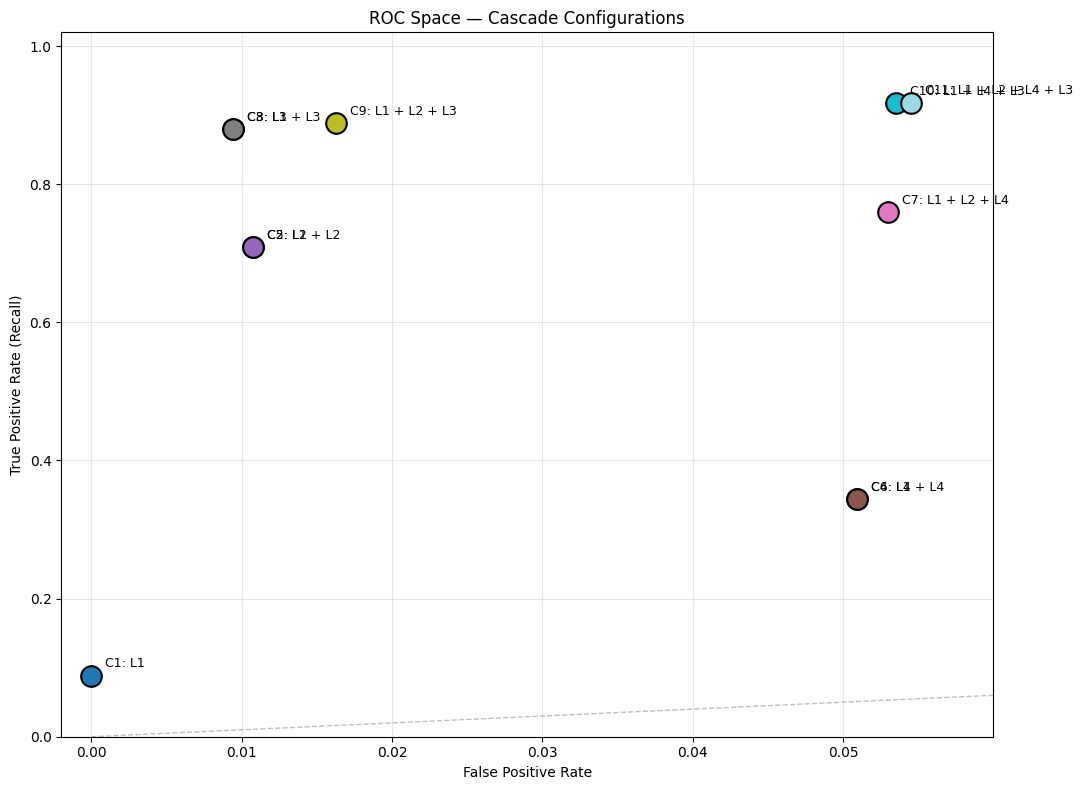

In [12]:
fig, ax = plt.subplots(figsize=(11, 8))
colors = plt.cm.tab20(np.linspace(0, 1, len(configurations)))

for i, (cid, layers, case, pred) in enumerate(configurations):
    fpr_i = results.loc[i, "FPR"]
    tpr_i = results.loc[i, "Recall"]
    ax.scatter(fpr_i, tpr_i, s=220, color=colors[i], edgecolor="black",
               linewidth=1.5, zorder=5)
    ax.annotate(f"{cid}: {layers}", (fpr_i, tpr_i),
                xytext=(10, 6), textcoords="offset points", fontsize=9)

ax.plot([0, 1], [0, 1], ls="--", color="gray", lw=1, alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Space — Cascade Configurations")
ax.set_xlim([-0.002, max(0.05, results['FPR'].max() * 1.1)])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.2 Confusion Matrices

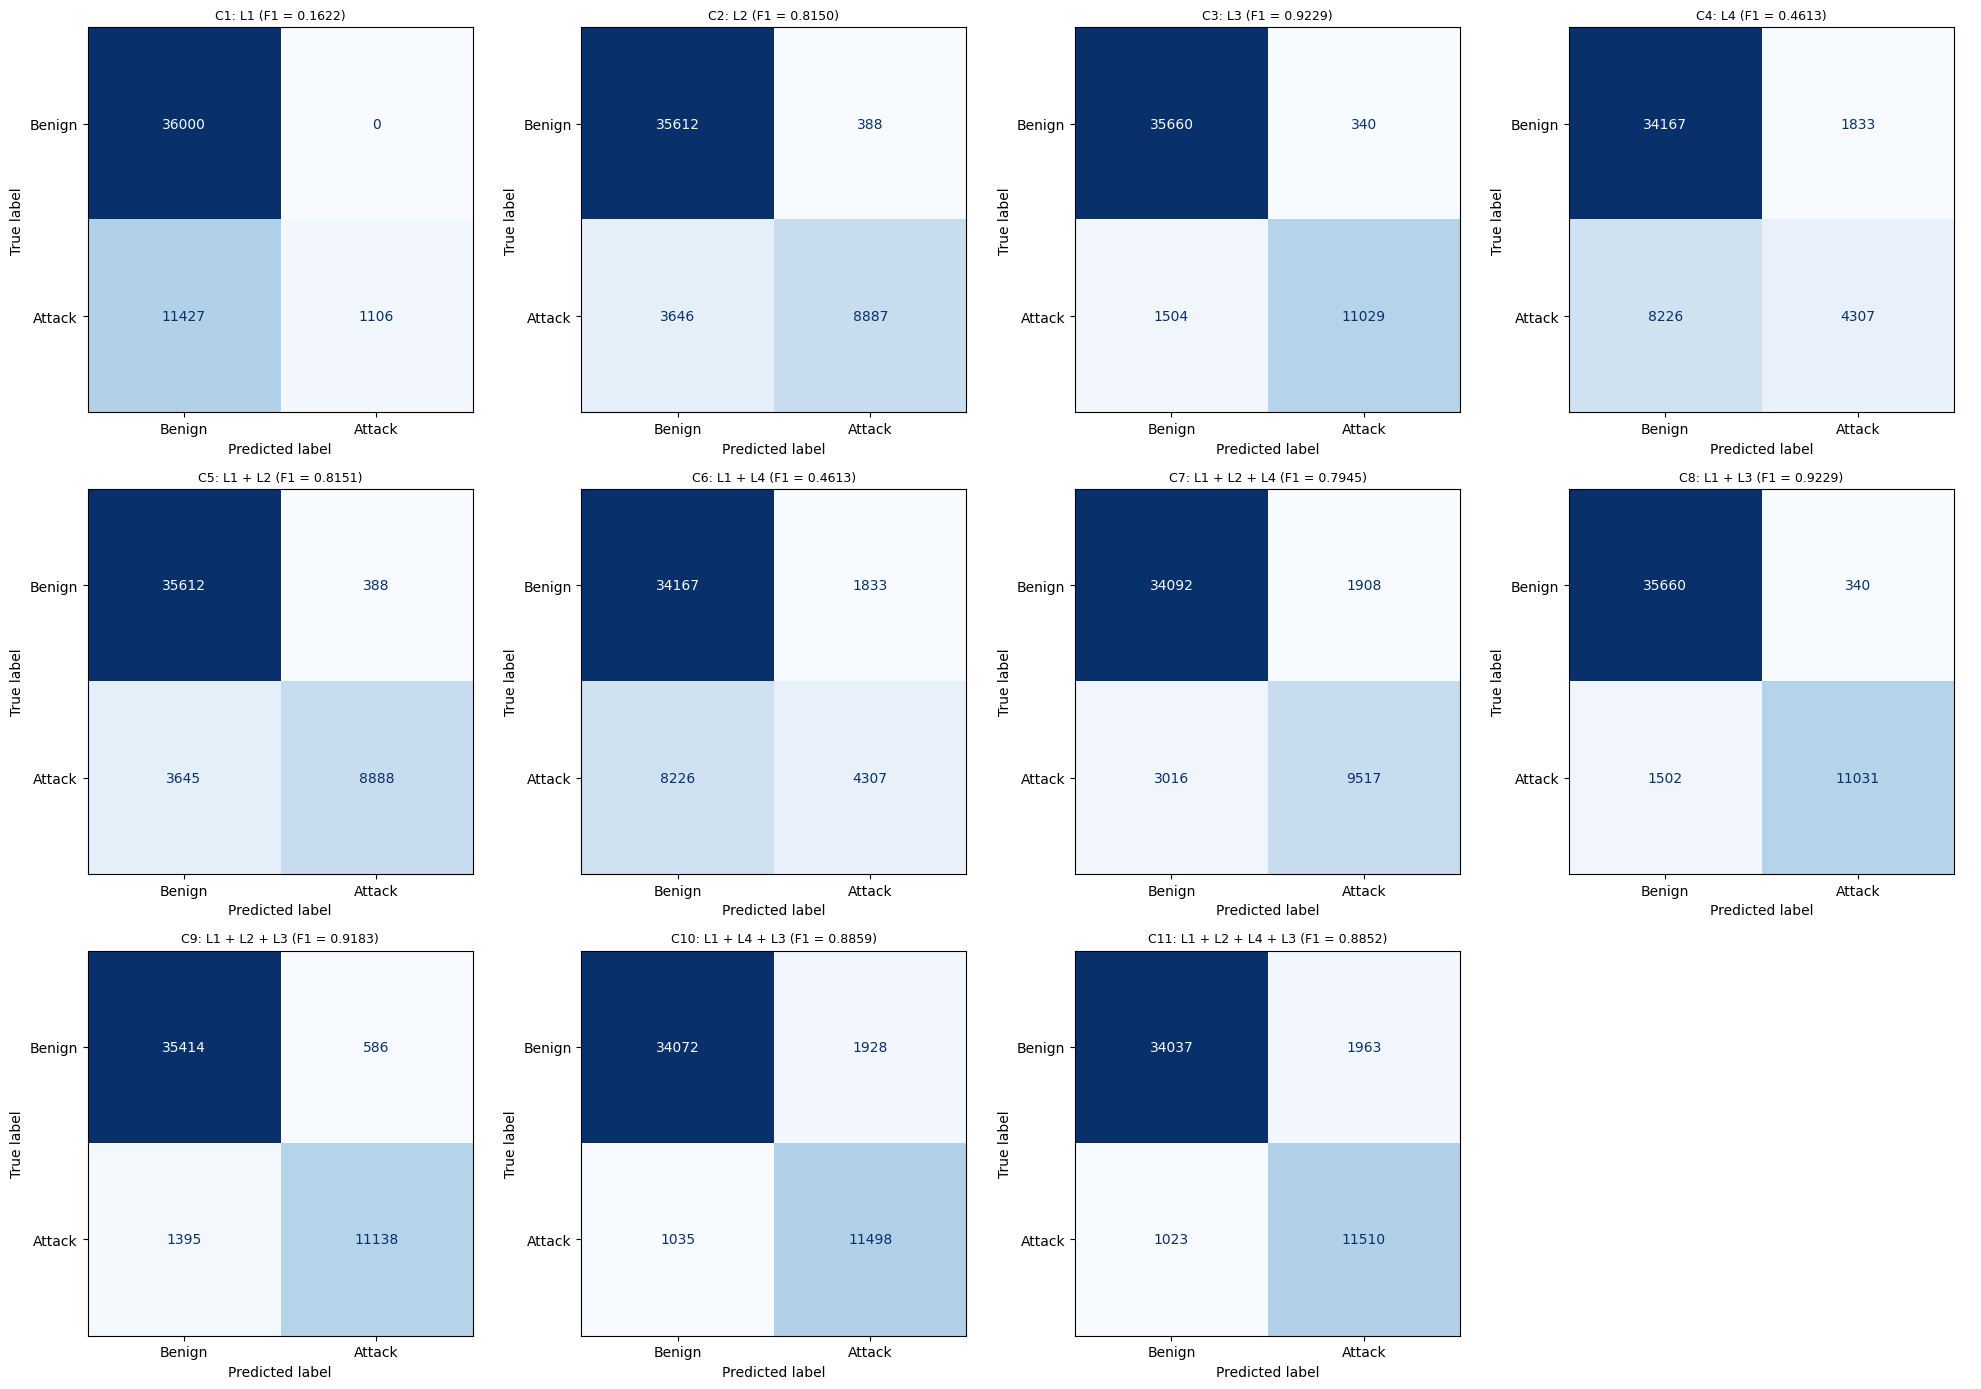

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
for ax in axes.flat:
    ax.axis("off")
for ax, (cid, layers, case, pred) in zip(axes.flat, configurations):
    ax.axis("on")
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred,
        display_labels=["Benign", "Attack"],
        cmap="Blues", ax=ax, colorbar=False,
    )
    f1 = f1_score(y_test, pred)
    ax.set_title(f"{cid}: {layers} (F1 = {f1:.4f})", fontsize=9)
plt.tight_layout()
plt.show()

---
# Why L2 (OC-SVM) Hurts the Cascade

The decisive comparison is **C5 (L1 + L3)** vs **C6 (L1 + L2 + L3)**. Adding OC-SVM on top of the 2-layer cascade trades precision for recall — but at what rate?

## 10. Marginal Contribution of Each Unsupervised Layer on Top of L1 + L3

For each unsupervised model (OC-SVM, Isolation Forest), look at exactly the samples it adds on top of the L1+L3 (C8) baseline — i.e. samples it flags that L1+L3 does not already flag — and check whether those additions are mostly true positives or false positives.

In [14]:
y_l1l3 = np.maximum(y_l1, y_l3)

def marginal_contribution(name, y_layer, y_layer_standalone):
    added_mask = (np.maximum(y_l1l3, y_layer) == 1) & (y_l1l3 == 0)
    added_tp = ((added_mask) & (y_test == 1)).sum()
    added_fp = ((added_mask) & (y_test == 0)).sum()
    added_total = added_mask.sum()
    added_precision = added_tp / added_total if added_total > 0 else 0.0
    standalone_p = precision_score(y_test, y_layer_standalone)

    print(f"{name} marginal contribution on top of L1 + L3 (C8):")
    print(f"  Total samples {name} added: {added_total:>5,}")
    print(f"    True positives:         {added_tp:>5,}  (additional attacks caught)")
    print(f"    False positives:        {added_fp:>5,}  (additional benign misclassified)")
    print(f"  Marginal precision in residual space: {added_precision:.4f}")
    print(f"  {name} standalone precision (full set): {standalone_p:.4f}")
    print(f"  -> precision collapse: {standalone_p:.4f} -> {added_precision:.4f}")
    print()
    return added_tp, added_fp, added_precision

l2_added_tp, l2_added_fp, l2_added_precision = marginal_contribution("L2 (OC-SVM)", y_l2, y_l2)
l4_added_tp, l4_added_fp, l4_added_precision = marginal_contribution("L4 (Isolation Forest)", y_l4, y_l4)

print("Interpretation: when an unsupervised layer sees only the residual that L3 hasn't")
print("already flagged, the easy-to-separate attacks are gone. What remains is a residual")
print("where the unsupervised model's anomaly boundary mostly fires on benign edge cases")
print("rather than real attacks — for both OC-SVM and Isolation Forest.")

L2 (OC-SVM) marginal contribution on top of L1 + L3 (C8):
  Total samples L2 (OC-SVM) added:   353
    True positives:           107  (additional attacks caught)
    False positives:          246  (additional benign misclassified)
  Marginal precision in residual space: 0.3031
  L2 (OC-SVM) standalone precision (full set): 0.9582
  -> precision collapse: 0.9582 -> 0.3031

L4 (Isolation Forest) marginal contribution on top of L1 + L3 (C8):
  Total samples L4 (Isolation Forest) added: 2,055
    True positives:           467  (additional attacks caught)
    False positives:        1,588  (additional benign misclassified)
  Marginal precision in residual space: 0.2273
  L4 (Isolation Forest) standalone precision (full set): 0.7015
  -> precision collapse: 0.7015 -> 0.2273

Interpretation: when an unsupervised layer sees only the residual that L3 hasn't
already flagged, the easy-to-separate attacks are gone. What remains is a residual
where the unsupervised model's anomaly boundary mostly f

## 11. Cost / Benefit vs C8 (L1 + L3) Baseline

Pairwise comparison of every other configuration against the Plan.md spec (C8). A negative ΔF1 means the alternative is worse.

In [15]:
baseline_idx = next(i for i, (cid, _, _, _) in enumerate(configurations) if cid == "C8")
baseline = results.loc[baseline_idx]

print(f"Baseline: {baseline['ID']}: {baseline['Configuration']} ({baseline['Case']})")
print(f"  F1 = {baseline['F1']:.4f}, P = {baseline['Precision']:.4f}, "
      f"R = {baseline['Recall']:.4f}, FP = {baseline['FP']:,}")
print()

comparison_rows = []
for i, row in results.iterrows():
    if i == baseline_idx:
        continue
    comparison_rows.append({
        "Config":     f"{row['ID']}: {row['Configuration']}",
        "Case":       row["Case"],
        "ΔF1":        f"{row['F1']        - baseline['F1']:+.4f}",
        "ΔPrecision": f"{row['Precision'] - baseline['Precision']:+.4f}",
        "ΔRecall":    f"{row['Recall']    - baseline['Recall']:+.4f}",
        "ΔFP":        f"{int(row['FP']    - baseline['FP']):+,}",
    })

print(pd.DataFrame(comparison_rows).to_string(index=False))

Baseline: C8: L1 + L3 (XGBoost only (Plan.md spec))
  F1 = 0.9229, P = 0.9701, R = 0.8802, FP = 340

                Config                                 Case     ΔF1 ΔPrecision ΔRecall    ΔFP
                C1: L1                       Regex baseline -0.7608    +0.0299 -0.7919   -340
                C2: L2                    OC-SVM standalone -0.1079    -0.0119 -0.1711    +48
                C3: L3                   XGBoost standalone -0.0001    -0.0000 -0.0002     +0
                C4: L4          Isolation Forest standalone -0.4616    -0.2686 -0.5365 +1,493
           C5: L1 + L2           Unsupervised only (OC-SVM) -0.1079    -0.0119 -0.1710    +48
           C6: L1 + L4 Unsupervised only (Isolation Forest) -0.4616    -0.2686 -0.5365 +1,493
      C7: L1 + L2 + L4             Unsupervised only (both) -0.1285    -0.1371 -0.1208 +1,568
      C9: L1 + L2 + L3                     OC-SVM + XGBoost -0.0046    -0.0201 +0.0085   +246
     C10: L1 + L4 + L3           Isolation Forest + X

---
# Conclusion

In [16]:
c8  = results.loc[results["ID"] == "C8"].iloc[0]   # L1 + L3 (Plan.md)
c9  = results.loc[results["ID"] == "C9"].iloc[0]   # + OC-SVM
c10 = results.loc[results["ID"] == "C10"].iloc[0]  # + Isolation Forest
c11 = results.loc[results["ID"] == "C11"].iloc[0]  # + both
c7  = results.loc[results["ID"] == "C7"].iloc[0]   # unsupervised only, no XGBoost
best = results.loc[best_f1_idx]

print("=" * 78)
print("UC3 CASCADE COMPARISON — CONCLUSION")
print("=" * 78)
print()
print(f"Best configuration by F1: {best['ID']}: {best['Configuration']} (F1 = {best['F1']:.4f})")
print()
print("Baseline (Plan.md):")
print(f"  C8  (L1 + L3):             F1 = {c8['F1']:.4f}, P = {c8['Precision']:.4f}, "
      f"R = {c8['Recall']:.4f}, FP = {int(c8['FP']):,}")
print()
print("Unsupervised models only (no XGBoost) — can they replace XGBoost?")
print(f"  C7  (L1 + L2 + L4):        F1 = {c7['F1']:.4f}, P = {c7['Precision']:.4f}, "
      f"R = {c7['Recall']:.4f}, FP = {int(c7['FP']):,}")
print(f"  -> {'BEATS' if c7['F1'] > c8['F1'] else 'does NOT beat'} the XGBoost-only baseline.")
print()
print("Adding one unsupervised model on top of L1 + L3:")
for cid_row, name in [(c9, "C9  (+ OC-SVM)"), (c10, "C10 (+ Isolation Forest)")]:
    delta_f1 = cid_row['F1'] - c8['F1']
    delta_fp = int(cid_row['FP'] - c8['FP'])
    delta_r  = cid_row['Recall'] - c8['Recall']
    print(f"  {name}: ΔF1 = {delta_f1:+.4f}, ΔRecall = {delta_r:+.4f}, ΔFP = {delta_fp:+,}")
print()
delta_f1_11 = c11['F1'] - c8['F1']
delta_fp_11 = int(c11['FP'] - c8['FP'])
delta_r_11  = c11['Recall'] - c8['Recall']
print(f"Adding both unsupervised models on top of L1 + L3:")
print(f"  C11 (everything): ΔF1 = {delta_f1_11:+.4f}, ΔRecall = {delta_r_11:+.4f}, ΔFP = {delta_fp_11:+,}")
print()

candidates_beat_baseline = [
    row for _, row in results.iterrows()
    if "L2" in row["Configuration"] or "L4" in row["Configuration"]
    for cond in [row["F1"] > c8["F1"]] if cond
]

if not candidates_beat_baseline:
    print("Recommendation: deploy 2-layer cascade (Regex + XGBoost).")
    print("  Plan.md is correct; neither unsupervised model (OC-SVM, Isolation Forest),")
    print("  alone or combined, improves on the XGBoost-only baseline. Remove both")
    print("  unsupervised layers from production.")
else:
    print("Recommendation: at least one unsupervised-layer configuration beats the")
    print("  XGBoost-only baseline on F1 — inspect the comparison table above before")
    print("  finalizing the production cascade.")

UC3 CASCADE COMPARISON — CONCLUSION

Best configuration by F1: C8: L1 + L3 (F1 = 0.9229)

Baseline (Plan.md):
  C8  (L1 + L3):             F1 = 0.9229, P = 0.9701, R = 0.8802, FP = 340

Unsupervised models only (no XGBoost) — can they replace XGBoost?
  C7  (L1 + L2 + L4):        F1 = 0.7945, P = 0.8330, R = 0.7594, FP = 1,908
  -> does NOT beat the XGBoost-only baseline.

Adding one unsupervised model on top of L1 + L3:
  C9  (+ OC-SVM): ΔF1 = -0.0046, ΔRecall = +0.0085, ΔFP = +246
  C10 (+ Isolation Forest): ΔF1 = -0.0371, ΔRecall = +0.0373, ΔFP = +1,588

Adding both unsupervised models on top of L1 + L3:
  C11 (everything): ΔF1 = -0.0378, ΔRecall = +0.0382, ΔFP = +1,623

Recommendation: deploy 2-layer cascade (Regex + XGBoost).
  Plan.md is correct; neither unsupervised model (OC-SVM, Isolation Forest),
  alone or combined, improves on the XGBoost-only baseline. Remove both
  unsupervised layers from production.


## Summary for Thesis Writeup

Every configuration that adds an unsupervised layer (OC-SVM, Isolation Forest, or both) on top
of the Regex + XGBoost baseline is **no better, and typically worse**, on F1 and precision than
the 2-layer baseline alone. Both unsupervised models' standalone precision looks reasonable in
isolation, but it collapses dramatically in the residual space behind XGBoost — by the time an
unsupervised layer sees the request stream, XGBoost has already filtered out the easy-to-separate
attacks. What remains is a residual whose distribution is closer to the benign support, so each
unsupervised model's anomaly boundary fires on benign edge cases more than on real attacks. The
unsupervised-only configurations (C5–C7, no XGBoost) fare no better, confirming this is not an
ordering artifact — regardless of whether the unsupervised models run before or after XGBoost,
the *set* of attacks they catch and the *set* of false positives they introduce are fixed by their
decision thresholds, and OR-composition only ever adds their false positives once the cheap
true positives are already covered by Regex + XGBoost.

This is consistent with the original `Plan.md` specification and supports a final 2-layer
architecture: **Regex (signature) + XGBoost (supervised classifier)**. Both OC-SVM and
Isolation Forest should be retained in the thesis as evaluated alternatives, with the empirical
evidence above framed as the rationale for excluding them from the deployed cascade.